In [1]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn plotly tensorflow streamlit PyPDF2 python-docx faiss-cpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 140.6 MB/s eta 0:00:00


In [4]:
import pandas as pd

# Upload file manually
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))
df.head()

Saving T1.csv to T1 (1).csv


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


In [9]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%d %m %Y %H:%M')
df = df.sort_values('Date/Time')

# Check missing values
print(df.isnull().sum())

# Fill missing values
df.ffill(inplace=True)

Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64


TASK 1 EDA

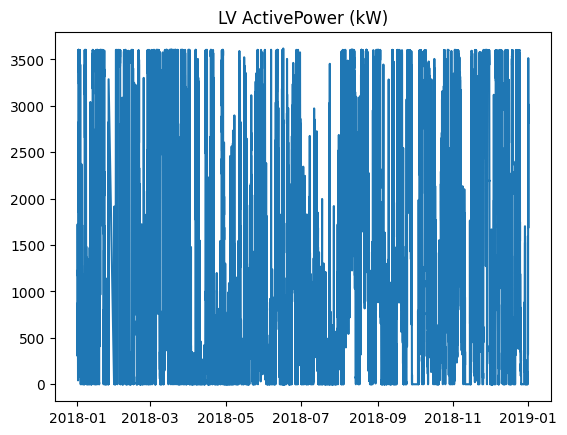

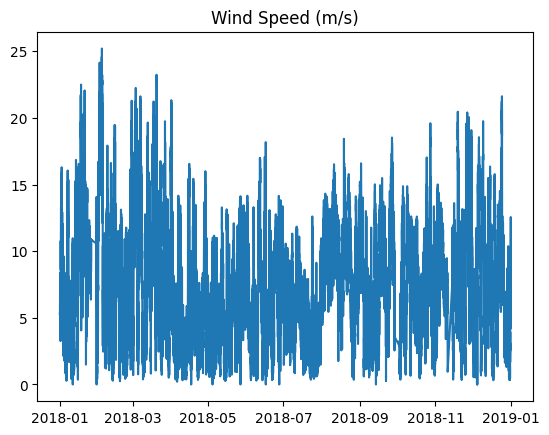

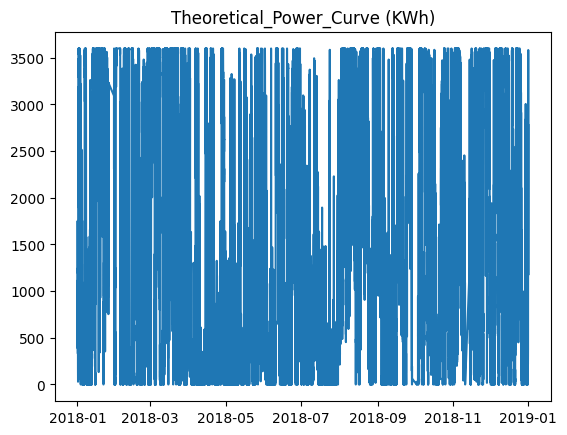

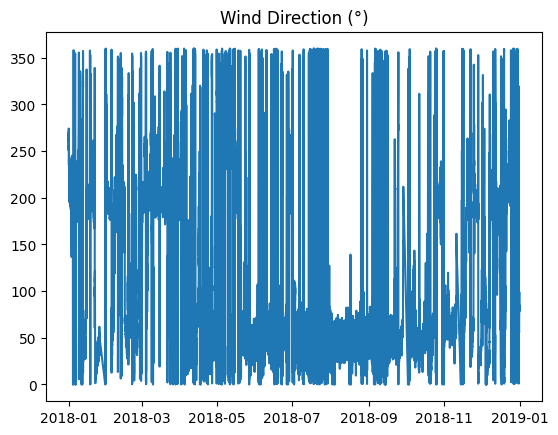

In [10]:
import matplotlib.pyplot as plt

cols = ['LV ActivePower (kW)', 'Wind Speed (m/s)',
        'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)'] # Corrected column name

for col in cols:
    plt.figure()
    plt.plot(df['Date/Time'], df[col])
    plt.title(col)
    plt.show()

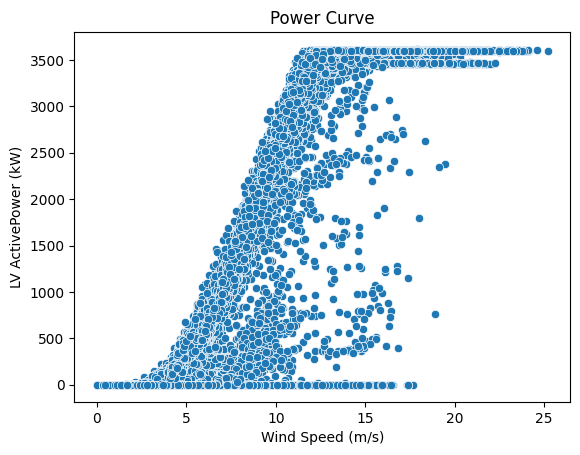

In [11]:
import seaborn as sns

sns.scatterplot(x=df['Wind Speed (m/s)'],
                y=df['LV ActivePower (kW)'])
plt.title("Power Curve")
plt.show()

TASK 2 — Time Series Forecasting

In [12]:
import numpy as np

def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

features = df[cols].values

X, y = create_sequences(features, 24)

# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(24, 4)),
    LSTM(32),
    Dense(4)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,212 (118.02 KB)

 Trainable params: 30,212 (118.02 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 1791434.8750
Epoch 2/5
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 1735533.2500
Epoch 3/5
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 1682878.2500
Epoch 4/5
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 1631993.8750
Epoch 5/5
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 1582423.0000


In [15]:
pred = model.predict(X_test)

316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [16]:
from sklearn.metrics import mean_squared_error

for i, col in enumerate(cols):
    mse = mean_squared_error(y_test[:, i], pred[:, i])
    print(col, "MSE:", mse)

LV ActivePower (kW) MSE: 3382727.941625914
Wind Speed (m/s) MSE: 10.60024367735896
Theoretical_Power_Curve (KWh) MSE: 3943647.482405878
Wind Direction (°) MSE: 9100.684059481822


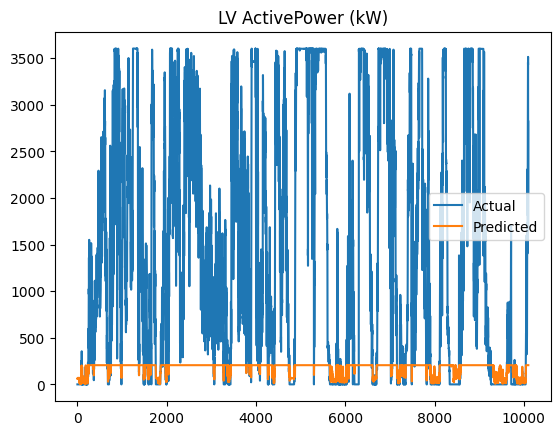

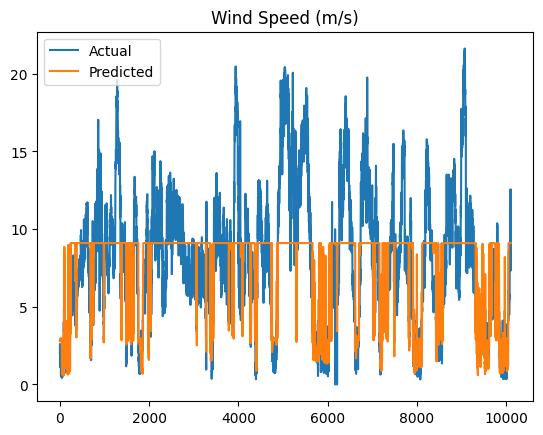

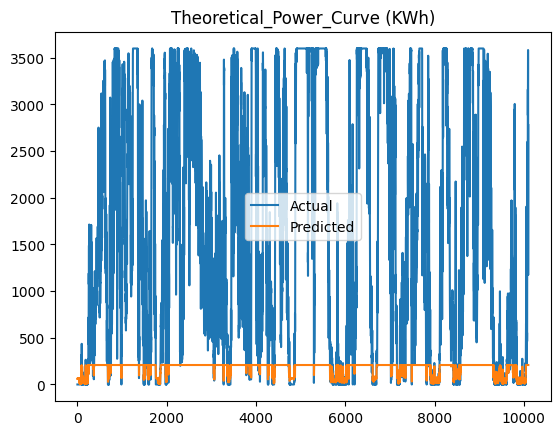

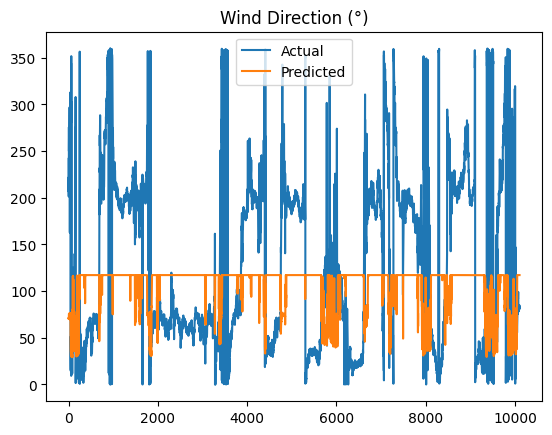

In [17]:
for i, col in enumerate(cols):
    plt.figure()
    plt.plot(y_test[:, i], label='Actual')
    plt.plot(pred[:, i], label='Predicted')
    plt.title(col)
    plt.legend()
    plt.show()

TASK 3 — Anomaly Detection

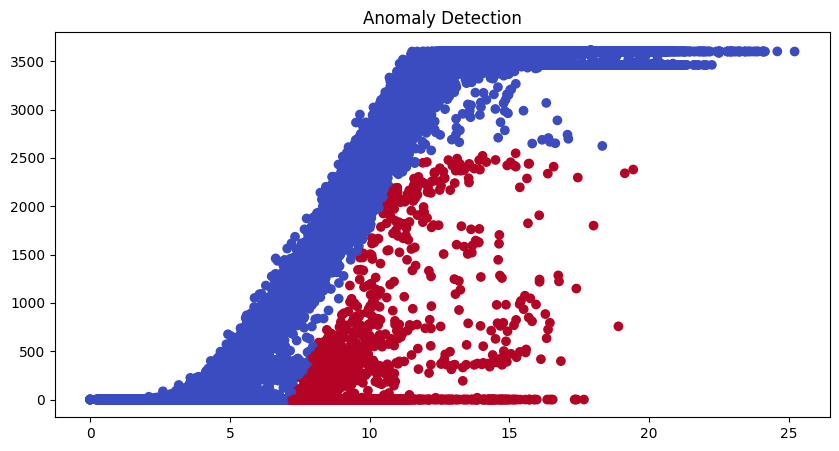

In [19]:
df['Deviation'] = abs(df['LV ActivePower (kW)'] - df['Theoretical_Power_Curve (KWh)'])

threshold = df['Deviation'].mean() + 2 * df['Deviation'].std()

df['Anomaly'] = df['Deviation'] > threshold

# Plot anomalies
plt.figure(figsize=(10,5))
plt.scatter(df['Wind Speed (m/s)'], df['LV ActivePower (kW)'],
            c=df['Anomaly'], cmap='coolwarm')
plt.title("Anomaly Detection")
plt.show()

TASK 4 — AI Performance Score

In [21]:
# Score calculation
df['Performance Score'] = (df['LV ActivePower (kW)'] /
                           df['Theoretical_Power_Curve (KWh)']) * 100

df['Performance Score'] = df['Performance Score'].clip(0, 100)

# Categorization
def categorize(score):
    if score > 80:
        return "Good"
    elif score > 50:
        return "Moderate"
    else:
        return "Poor"

df['Category'] = df['Performance Score'].apply(categorize)

# Suggestions
def suggestion(cat):
    if cat == "Good":
        return "Operating efficiently"
    elif cat == "Moderate":
        return "Needs inspection"
    else:
        return "Immediate maintenance required"

df['Suggestion'] = df['Category'].apply(suggestion)

df[['Performance Score','Category','Suggestion']].head()

,Performance Score,Category,Suggestion
0,91.285468,Good,Operating efficiently
1,87.277152,Good,Operating efficiently
2,78.377226,Moderate,Needs inspection
3,81.306625,Good,Operating efficiently
4,77.414764,Moderate,Needs inspection


TASK 5 — RAG SYSTEM

In [23]:
uploaded = files.upload()

Saving ts-wind-generation-maintenance-march-2018.pdf to ts-wind-generation-maintenance-march-2018.pdf


In [24]:
from PyPDF2 import PdfReader

text = ""

for file in uploaded:
    if file.endswith(".pdf"):
        reader = PdfReader(file)
        for page in reader.pages:
            text += page.extract_text()

In [25]:
chunks = text.split('\n')
chunks = [c for c in chunks if len(c) > 50]

In [26]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

model_emb = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model_emb.encode(chunks)

index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(np.array(embeddings))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [27]:
def search(query):
    q_emb = model_emb.encode([query])
    D, I = index.search(np.array(q_emb), k=3)
    return [chunks[i] for i in I[0]]

In [28]:
query = "How to maintain wind turbine?"
results = search(query)

for r in results:
    print(r)

from throughout the wind turbine can identify many preventative maintenance needs
identified early.Wind Turbine Operation & Maintenance Issues | 9
an, D. and Mo, J. (2017). “Life cycle analysis and maintenance analyses of wind turbines.”


UI INTERFACE

In [32]:
!pip install gradio

In [34]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt

# The DataFrame 'df' is already loaded and preprocessed from previous steps.
# Remove the line attempting to load 'your_dataset.csv'.
# df = pd.read_csv("your_dataset.csv")
# df['Date/Time'] = pd.to_datetime(df['Date/Time'])

def plot_graph(param):
    plt.figure()
    plt.plot(df['Date/Time'], df[param])
    plt.title(param)
    return plt

ui = gr.Interface(
    fn=plot_graph,
    inputs=gr.Dropdown([
        'LV ActivePower (kW)',
        'Wind Speed (m/s)',
        'Theoretical_Power_Curve (KWh)',
        'Wind Direction (°)'
    ]),
    outputs="plot",
    title="Wind Turbine Dashboard"
)

ui.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0bb63074dd909862d4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [35]:
def rag_answer(query):
    results = search(query)
    return "\n\n".join(results)

chat_ui = gr.Interface(
    fn=rag_answer,
    inputs="text",
    outputs="text",
    title="Wind Turbine RAG Chatbot"
)

chat_ui.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://80f35f430f8d1757b0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [36]:
import plotly.express as px

fig = px.line(df, x='Date/Time', y='LV ActivePower (kW)')
fig.show()

Dropdown(description='Select:', options=('LV ActivePower (kW)', 'Wind Speed (m/s)'), value='LV ActivePower (kW…

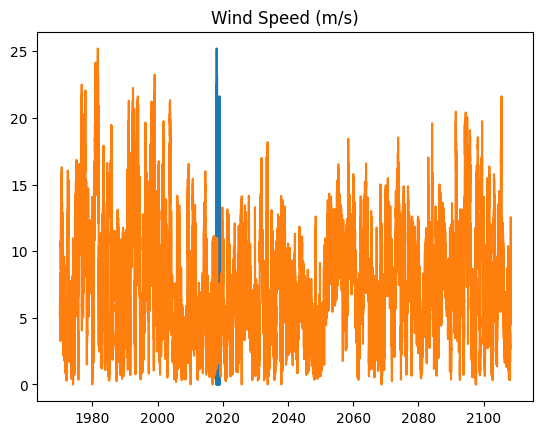

In [37]:
import ipywidgets as widgets
from IPython.display import display

dropdown = widgets.Dropdown(
    options=[
        'LV ActivePower (kW)',
        'Wind Speed (m/s)'
    ],
    description='Select:'
)

def update(change):
    plt.plot(df[change.new])
    plt.show()

dropdown.observe(update, names='value')
display(dropdown)